In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt 

def parse_matrix_file(path):
    """Parse a file written by print_matrix_to_file -> (label, np.ndarray of shape (rows, cols))."""
    text = open(path).read()

    # split "label = [ ... ]"
    m = re.search(r"(\w+)\s*=\s*\[(.*)\]", text, re.DOTALL)
    assert m, f"no 'label = [...]' found in {path}"
    label, body = m.group(1), m.group(2)

    # each inner [ ... ] is a row
    rows = re.findall(r"\[([^\[\]]*)\]", body)
    data = [[float(v) for v in r.split(",") if v.strip()] for r in rows]

    return label, np.array(data)

In [68]:
l, data = parse_matrix_file("compl_gradient_output.txt")
data = data[120]
data = data.reshape(-1)
data.shape

(342,)

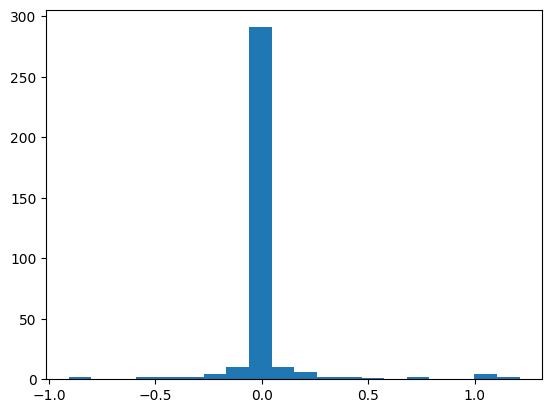

In [69]:
plt.hist(data[np.abs(data) < 1000], bins=20)
plt.show()

In [65]:
np.sum(data<0.0) / np.sum(data>0.0)

np.float64(1.408450704225352)

np.int64(5673)